<a href="https://colab.research.google.com/github/Anderson-Amilcar01/Anderson-Amilcar01.github.io/blob/main/segundo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
%cd /content
import os
HOME = os.getcwd()

/content


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
%cd {HOME}
!git clone https://github.com/IDEA-Research/GroundingDINO.git
%cd {HOME}/GroundingDINO

/content
Cloning into 'GroundingDINO'...
remote: Enumerating objects: 463, done.
remote: Total 463 (delta 0), reused 0 (delta 0), pack-reused 463 (from 1)
Receiving objects: 100% (463/463), 12.91 MiB | 27.95 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/GroundingDINO


In [ ]:
!pip install -e .
!pip install opencv-python matplotlib

Obtaining file:///content/GroundingDINO
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 15.5 MB/s eta 0:00:00
  Running setup.py develop for groundingdino


In [ ]:
!mkdir -p {HOME}/weights
%cd {HOME}/weights
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swinb_ogc.pth
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth

/content/weights


In [ ]:
!wget -O {HOME}/GroundingDINO/groundingdino/config/GroundingDINO_SwinB_cfg.py https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinB_cfg.py
!wget -O {HOME}/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/refs/heads/main/groundingdino/config/GroundingDINO_SwinT_OGC.py

--2025-09-04 13:15:28--  https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinB_cfg.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1007 [text/plain]
Saving to: ‘/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinB_cfg.py’

/content/GroundingD 100%[===================>]    1007  --.-KB/s    in 0s      

2025-09-04 13:15:29 (47.7 MB/s) - ‘/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinB_cfg.py’ saved [1007/1007]

--2025-09-04 13:15:29--  https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/refs/heads/main/groundingdino/config/GroundingDINO_SwinT_OGC.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, .

In [ ]:
import os
%cd {HOME}/GroundingDINO
from groundingdino.util.inference import load_model, load_image, predict, annotate

config_path = f"{HOME}/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
weights_path = f"{HOME}/weights/groundingdino_swint_ogc.pth"

model = load_model(config_path, weights_path)

/content/GroundingDINO


final text_encoder_type: bert-base-uncased


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

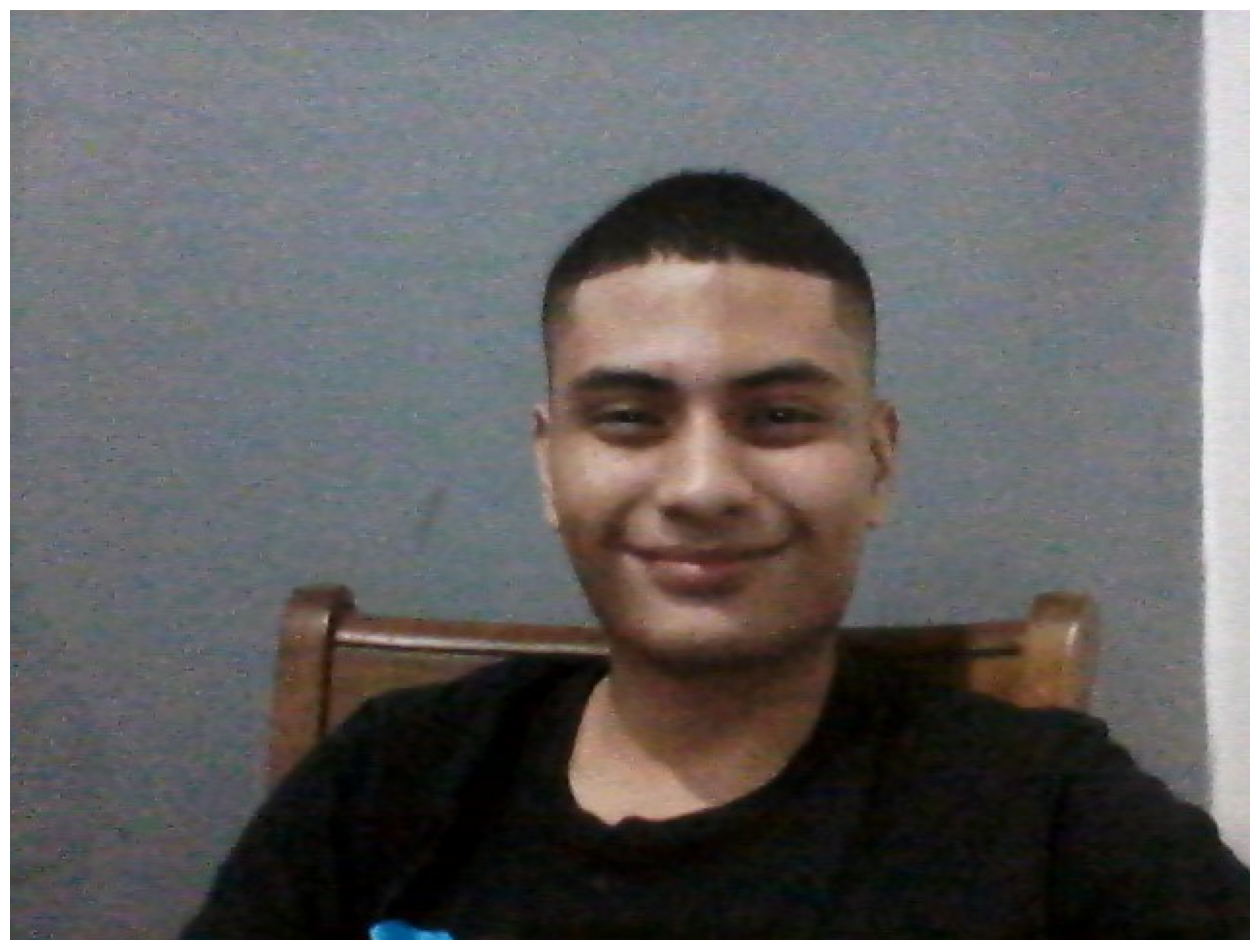

In [ ]:
#Importar bibliotecas adicionales
import os
import supervision as sv
#Definir la imagen y el texto de referencia para la detecction de objetos
IMAGE_NAME="/content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/imagenes/user.1.3.jpg"
IMAGE_NAME=os.path.join(HOME,'data',IMAGE_NAME)
TEXT_PROMPT="user.1"

BOX_THRESHOLD=0.80
TEXT_THRESHOLD=0.25
#CARGAR LA IMAGEN
image_source, image = load_image(IMAGE_NAME)
#Realizar la predicción de objetos
boxes,logits,phrases=predict(
    model=model,
    image=image,
    caption=TEXT_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
    device='cpu'
)
#Anotar la imagen con las dectecciones
annotated_frame=annotate(
    image_source=image_source,
    boxes=boxes,
    logits=logits,
    phrases=phrases
)
#Mostrar la imagen anotada
%matplotlib inline
sv.plot_image(annotated_frame, (16,16))

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!find "/content/drive/My Drive/Colab Notebooks/Deteccion LESSA/imagenes" -type d -name ".ipynb_checkpoints" -exec rm -rf {} +

In [ ]:
import os
from time import time
import cv2
import torch
from PIL import Image
from GroundingDINO.groundingdino.util.inference import load_model, predict, annotate #Carga de modelos
import GroundingDINO.groundingdino.datasets.transforms as T #Preprocesar imágenes.

In [ ]:
DEVICE=torch.device('cuda:0'if torch.cuda.is_available() else 'cpu')

In [ ]:
def read_imagenes_from_folder(folder_path):
  images = [] # lista para almacenar las imágenes
  clases = [] # lista para almacenar los nombres de las clases (sin extensión)
  lista = os.listdir(folder_path) # lista de archivos en la carpeta especificada

# Itera sobre los archivos en la carpeta
  for lis in lista:
      img_path = os.path.join(folder_path, lis) # Obtiene la ruta completa de la imagen
      img = cv2.imread(img_path) # Lee la imagen usando OpenCV
      images.append(img) # Agrega la imagen a la lista de imágenes
      clases.append(os.path.splitext(lis)[0]) # Agrega el nombre del archivo (sin extensión) a la lista de clases

  return images, clases # Retorna las listas de imágenes y clases

In [ ]:
import os
from time import time
import cv2

# Función para guardar los resultados de la detección
def save_results(image, boxes, class_id, out_folder):
    # Asegura que la carpeta de salida exista
    os.makedirs(out_folder, exist_ok=True)

    # Genera un nombre de archivo único usando el tiempo actual
    time_now = str(time()).replace('.', '')

    # Guarda la imagen original con detecciones
    cv2.imwrite(f"{out_folder}/{time_now}.jpg", image)

    # Guarda TODAS las cajas en el .txt
    with open(f"{out_folder}/{time_now}.txt", 'w') as f:
        for box in boxes:
            xc, yc, an, al = box
            # Normaliza valores a [0,1]
            xc, yc, an, al = max(0, min(1, xc)), max(0, min(1, yc)), max(0, min(1, an)), max(0, min(1, al))
            f.write(f"{class_id} {xc} {yc} {an} {al}\n")


In [ ]:
import os
import cv2
import torch
from time import time
from PIL import Image
import groundingdino.datasets.transforms as T

# Selección de dispositivo
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Función para leer imágenes
def read_images_from_folder(folder_path):
    images, clases = [], []
    for lis in os.listdir(folder_path):
        img_path = os.path.join(folder_path, lis)
        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)
            clases.append(os.path.splitext(lis)[0])
    return images, clases

# Guardar resultados
def save_results(image, boxes, class_id, out_folder):
    xc, yc, an, al = boxes[0]
    xc, yc, an, al = max(0, min(1, xc)), max(0, min(1, yc)), max(0, min(1, an)), max(0, min(1, al))
    list_info = [f"{class_id} {xc} {yc} {an} {al}"]

    time_now = str(time()).replace('.', '')
    cv2.imwrite(f"{out_folder}/{time_now}.jpg", image)

    with open(f"{out_folder}/{time_now}.txt", 'a') as f:
        for info in list_info:
            f.write(info + "\n")

# Función principal
def main():
    img_folder_path = '/content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/imagenes'
    out_folder_path = '/content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones'
    class_id = 0
    save_results_flag = True

    # Asegura la carpeta de salida
    os.makedirs(out_folder_path, exist_ok=True)

    images, classes = read_images_from_folder(img_folder_path)
    num_images = len(images)

    print(f"Imagenes: {num_images}")
    print(f"Nombres: {classes}")

    config_path = "/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
    check_point_path = '/content/weights/groundingdino_swint_ogc.pth'

    model = load_model(config_path, check_point_path)

    text_prompt = 'person'
    box_threshold = 0.80
    text_threshold = 0.25

    for idx, img in enumerate(images):
        print("------------------//--------------------")
        print(f"Image: {classes[idx]}")

        img_copy = img.copy()

        transform = T.Compose([
            T.RandomResize([800], max_size=1333),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        img_source = Image.fromarray(img).convert("RGB")
        img_transform, _ = transform(img_source, None)

        boxes, logits, phrases = predict(
            model=model,
            image=img_transform,
            caption=text_prompt,
            box_threshold=box_threshold,
            text_threshold=text_threshold,
            device=DEVICE
        )

        print(f"Detecciones encontradas: {len(boxes)}")  # 👈 debug

        if len(boxes) != 0 and save_results_flag:
            save_results(img_copy, boxes, class_id, out_folder_path)

if __name__ == "__main__":
    main()


Imagenes: 15
Nombres: ['user.1.12', 'user.1.11', 'user.1.9', 'user.1.10', 'user.1.13', 'user.1.14', 'user.1.15', 'user.1.1', 'user.1.2', 'user.1.4', 'user.1.3', 'user.1.5', 'user.1.6', 'user.1.7', 'user.1.8']
final text_encoder_type: bert-base-uncased
------------------//--------------------
Image: user.1.12
Detecciones encontradas: 1
------------------//--------------------
Image: user.1.11
Detecciones encontradas: 0
------------------//--------------------
Image: user.1.9
Detecciones encontradas: 1
------------------//--------------------
Image: user.1.10
Detecciones encontradas: 0
------------------//--------------------
Image: user.1.13
Detecciones encontradas: 1
------------------//--------------------
Image: user.1.14
Detecciones encontradas: 1
------------------//--------------------
Image: user.1.15
Detecciones encontradas: 0
------------------//--------------------
Image: user.1.1
Detecciones encontradas: 1
------------------//--------------------
Image: user.1.2
Detecciones e

In [ ]:
!zip -r "/content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/usuario.zip" "/content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones"

updating: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/ (stored 0%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569990140827358.jpg (deflated 3%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569990140827358.txt (deflated 27%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569990791337729.jpg (deflated 3%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569990791337729.txt (deflated 27%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569991387760189.jpg (deflated 3%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569991387760189.txt (deflated 27%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569991681875517.jpg (deflated 3%)
  adding: content/drive/MyDrive/Colab Notebooks/Deteccion LESSA/Anotaciones/17569991681875517.txt (deflated 27%)
  adding: c